# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [33]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [34]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [35]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [36]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype=np.int32) - 1
    X_test  = np.loadtxt(f"{root_dir}/test/X_test.txt",   dtype=np.float32)
    y_test  = np.loadtxt(f"{root_dir}/test/y_test.txt",   dtype=np.int32)  - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()
    
class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes  = len(class_names)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"num_features={num_features}, num_classes={num_classes}")

X_train: (7352, 561), X_test: (2947, 561)
num_features=561, num_classes=6


## 5. Quick Inspection


In [37]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
summary_df = pd.DataFrame({
    "Class Index":   list(range(num_classes)),
    "Class Name":    class_names,
    "Train Samples": [int(np.sum(y_train == i)) for i in range(num_classes)]
})
print(summary_df.to_string(index=False))

 Class Index         Class Name  Train Samples
           0            WALKING           1226
           1   WALKING_UPSTAIRS           1073
           2 WALKING_DOWNSTAIRS            986
           3            SITTING           1286
           4           STANDING           1374
           5             LAYING           1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [38]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [39]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 2s 10ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves


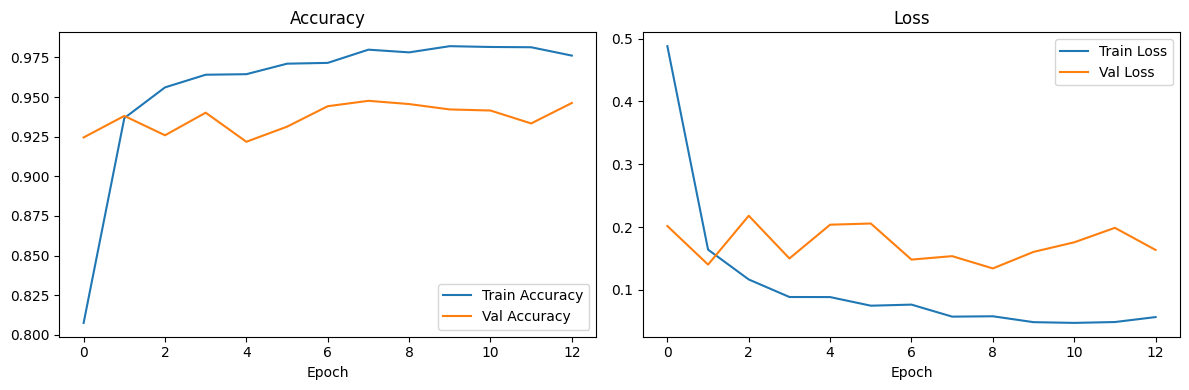

In [40]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


Baseline Keras test accuracy: 0.9220

                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



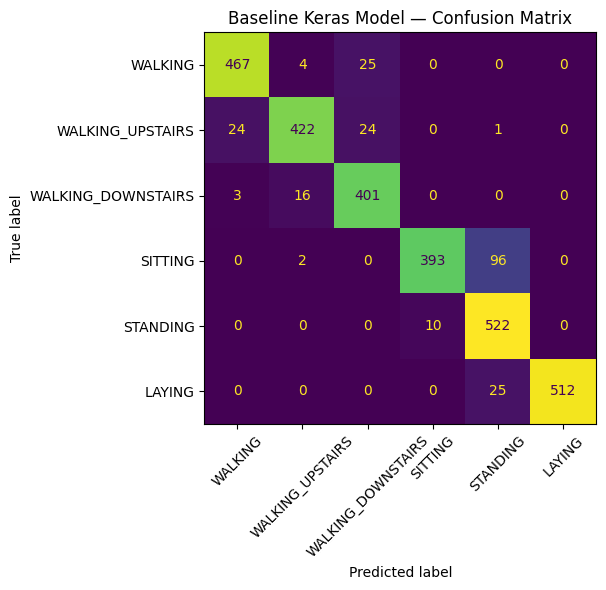

In [41]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob_baseline = baseline_model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_prob_baseline, axis=1)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Keras test accuracy: {baseline_acc:.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Baseline Keras Model — Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [42]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    indices = np.random.choice(len(X_train), 300, replace=False)
    for i in indices:
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details['dtype'] in (np.int8, np.uint8):
            x = (x / input_scale + input_zero_point).astype(input_details['dtype'])
        else:
            x = x.astype(input_details['dtype'])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details['dtype'] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [43]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
tflite_fp32     = convert_to_tflite_fp32(baseline_model)
tflite_dynrng   = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16     = convert_to_tflite_float16(baseline_model)
tflite_ptq_int8 = convert_to_tflite_int8(baseline_model)

size_fp32     = save_binary_model(tflite_fp32,     "baseline_fp32.tflite")
size_dynrng   = save_binary_model(tflite_dynrng,   "baseline_dynamic_range.tflite")
size_fp16     = save_binary_model(tflite_fp16,     "baseline_fp16.tflite")
size_ptq_int8 = save_binary_model(tflite_ptq_int8, "baseline_ptq_int8.tflite")

acc_fp32,     pred_fp32     = evaluate_tflite_model(tflite_fp32,     X_test, y_test)
acc_dynrng,   pred_dynrng   = evaluate_tflite_model(tflite_dynrng,   X_test, y_test)
acc_fp16,     pred_fp16     = evaluate_tflite_model(tflite_fp16,     X_test, y_test)
acc_ptq_int8, pred_ptq_int8 = evaluate_tflite_model(tflite_ptq_int8, X_test, y_test)

print(f"FP32          — Acc: {acc_fp32:.4f}   Size: {size_fp32:.1f} KB")
print(f"Dynamic Range — Acc: {acc_dynrng:.4f}   Size: {size_dynrng:.1f} KB")
print(f"Float16       — Acc: {acc_fp16:.4f}   Size: {size_fp16:.1f} KB")
print(f"PTQ Int8      — Acc: {acc_ptq_int8:.4f}   Size: {size_ptq_int8:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmp7b8o86zl/assets


INFO:tensorflow:Assets written to: /tmp/tmp7b8o86zl/assets
2026-04-23 11:17:51.391798: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 11:17:51.391891: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 11:17:51.392182: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7b8o86zl
2026-04-23 11:17:51.392918: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 11:17:51.392932: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7b8o86zl
2026-04-23 11:17:51.395997: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 11:17:51.464505: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp7b8o86zl
2026-04-23 11:17:51.481401: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpi7yd_s52/assets


INFO:tensorflow:Assets written to: /tmp/tmpi7yd_s52/assets
2026-04-23 11:17:52.125737: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 11:17:52.125793: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 11:17:52.126155: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi7yd_s52
2026-04-23 11:17:52.126997: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 11:17:52.127018: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpi7yd_s52
2026-04-23 11:17:52.130108: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 11:17:52.176233: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpi7yd_s52
2026-04-23 11:17:52.186325: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpevlhdoow/assets


INFO:tensorflow:Assets written to: /tmp/tmpevlhdoow/assets
2026-04-23 11:17:52.924786: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 11:17:52.924834: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 11:17:52.924976: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpevlhdoow
2026-04-23 11:17:52.925716: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 11:17:52.925729: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpevlhdoow
2026-04-23 11:17:52.928073: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 11:17:52.967069: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpevlhdoow
2026-04-23 11:17:52.977430: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpw8sq4yiq/assets


INFO:tensorflow:Assets written to: /tmp/tmpw8sq4yiq/assets
/home/metal/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 11:17:54.740221: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 11:17:54.740277: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 11:17:54.740451: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpw8sq4yiq
2026-04-23 11:17:54.741471: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 11:17:54.741488: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpw8sq4yiq
2026-04-23 11:17:54.745195: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

FP32          — Acc: 0.9220   Size: 726.8 KB
Dynamic Range — Acc: 0.9213   Size: 186.1 KB
Float16       — Acc: 0.9220   Size: 365.8 KB
PTQ Int8      — Acc: 0.9223   Size: 185.4 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [44]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_results = pd.DataFrame({
    "Model Family":   ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format":         ["FP32 TFLite", "Dynamic Range", "Float16", "PTQ Int8"],
    "Test Accuracy":  [acc_fp32, acc_dynrng, acc_fp16, acc_ptq_int8],
    "Model Size (KB)":[size_fp32, size_dynrng, size_fp16, size_ptq_int8]
})
print(ptq_results.to_string(index=False))

Model Family        Format  Test Accuracy  Model Size (KB)
    Baseline   FP32 TFLite       0.921955       726.750000
    Baseline Dynamic Range       0.921276       186.140625
    Baseline       Float16       0.921955       365.773438
    Baseline      PTQ Int8       0.922294       185.351562


/tmp/ipykernel_520/525028663.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ptq_results["Format"], rotation=15, ha="right")
/tmp/ipykernel_520/525028663.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(ptq_results["Format"], rotation=15, ha="right")


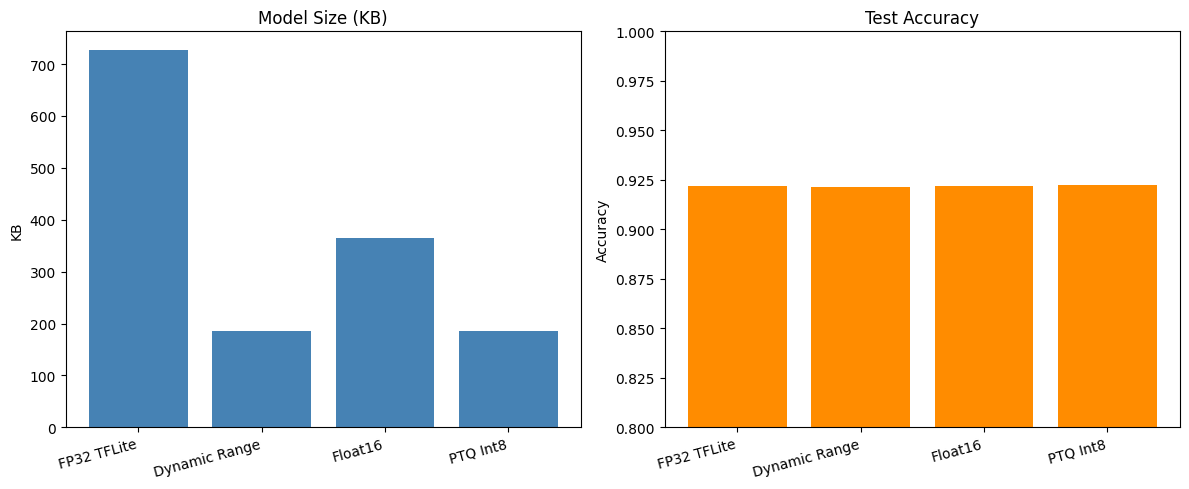

In [45]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(ptq_results["Format"], ptq_results["Model Size (KB)"], color="steelblue")
axes[0].set_title("Model Size (KB)")
axes[0].set_ylabel("KB")
axes[0].set_xticklabels(ptq_results["Format"], rotation=15, ha="right")

axes[1].bar(ptq_results["Format"], ptq_results["Test Accuracy"], color="darkorange")
axes[1].set_title("Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.8, 1.0)
axes[1].set_xticklabels(ptq_results["Format"], rotation=15, ha="right")

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


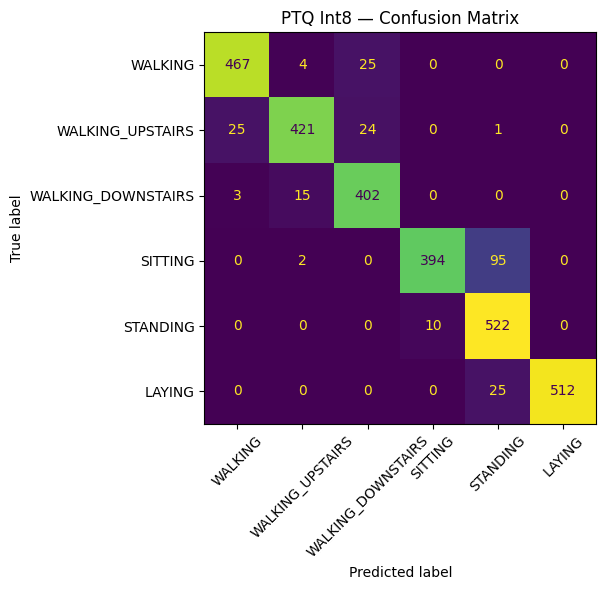

                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.96      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [46]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
cm_ptq_int8 = confusion_matrix(y_test, pred_ptq_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ptq_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('PTQ Int8 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_ptq_int8, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [47]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
qat_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_1 (Quantize  (None, 561)               3         
 Layer)                                                          
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [48]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 2s 8ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 2s 25ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [=========

### Evaluate the QAT Keras Model


In [49]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
y_prob_qat = qat_model.predict(X_test, verbose=0)
y_pred_qat = np.argmax(y_prob_qat, axis=1)
qat_keras_acc = accuracy_score(y_test, y_pred_qat)
print(f"QAT Keras test accuracy: {qat_keras_acc:.4f}")
print()
print(classification_report(y_test, y_pred_qat, target_names=class_names))

QAT Keras test accuracy: 0.9321

                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [50]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
tflite_qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8   = save_binary_model(tflite_qat_int8, "qat_int8.tflite")
acc_qat_int8, pred_qat_int8 = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)
print(f"QAT Int8 TFLite — Acc: {acc_qat_int8:.4f}   Size: {size_qat_int8:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmp0rx18aal/assets


INFO:tensorflow:Assets written to: /tmp/tmp0rx18aal/assets


QAT Int8 TFLite — Acc: 0.9325   Size: 185.8 KB


/home/metal/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 11:18:04.956755: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 11:18:04.956807: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 11:18:04.956947: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0rx18aal
2026-04-23 11:18:04.958685: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 11:18:04.958700: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0rx18aal
2026-04-23 11:18:04.964453: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 11:18:05.050975: I tensorflow/cc/saved_model/loader

## 12. PTQ Int8 vs QAT Int8


In [51]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame({
    "Model":           ["PTQ Int8", "QAT Int8"],
    "Test Accuracy":   [acc_ptq_int8, acc_qat_int8],
    "Model Size (KB)": [size_ptq_int8, size_qat_int8]
})
print(comparison_df.to_string(index=False))

   Model  Test Accuracy  Model Size (KB)
PTQ Int8       0.922294       185.351562
QAT Int8       0.932474       185.773438


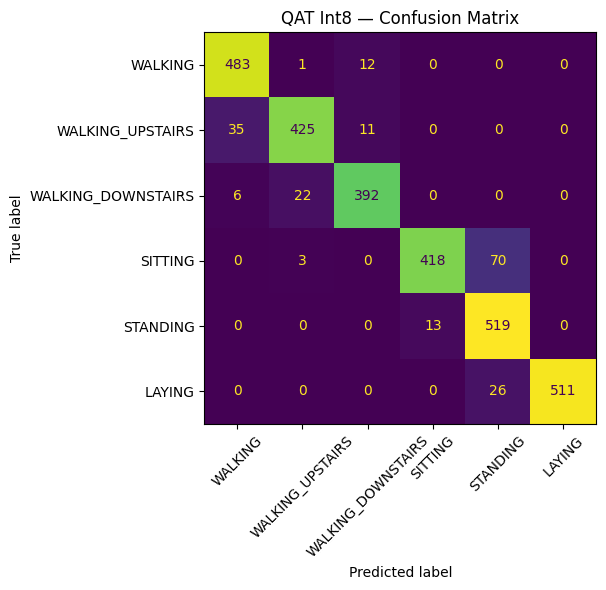

In [52]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat_int8 = confusion_matrix(y_test, pred_qat_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('QAT Int8 — Confusion Matrix')
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
### Q1. Which quantization method gave the smallest model size?
Full int8 post-training quantization gave the smallest size because everything is forced into 8-bit, so the entire model is compressed as much as possible.

### Q2. Which quantization method gave the best accuracy among the TFLite models?
Quantization-aware training (QAT) gave the best accuracy since the model is trained while simulating quantization, so it adapts to precision loss.

### Q3. Did QAT improve the final int8 model compared with PTQ int8?
Yes, QAT improved performance because PTQ compresses after training and introduces error, while QAT accounts for that error during training.

### Q4. Why is this dataset a good fit for TinyML?
The dataset is structured and based on sensor data (accelerometer and gyroscope), which matches the type of data used in embedded TinyML applications.

### Q5. Which model would you deploy and why?
The QAT int8 model because it provides near float-level accuracy while keeping memory usage low and inference fast, which is ideal for resource-constrained devices like ESP32.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
